In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

import utils
from utils import *
from circuit_extract import visualize_circuit_masks
import circuit_extract as ce
import inference
import train
from copy import deepcopy

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'libc10_cuda.so: cannot open shared object file: No such file or directory'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we

In [2]:
import importlib

importlib.reload(utils)
importlib.reload(inference)
importlib.reload(train)
importlib.reload(ce)

<module 'circuit_extract' from '/home/cabbagepatch/Code/MI/vast/Mechanistic-Interpretability/circuit_extract.py'>

In [3]:
def model_config(ds_name: str, lr: float, epochs: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "epochs": epochs, 
        "lr": lr,
        # "pfrac": pfrac,
    }

def circuit_config(ds_name: str, lr: float, cepochs: int, k_w: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "cepochs": cepochs, 
        "lr": lr,
        "k_w": k_w,
    }
    

### Train Sparse Model ###

In [ ]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (1, 28, 28)
model = inference.CNN(nc=1, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [ ]:
print("\n--- Phase 2: Train Sparse Baseline ---")

epochs = 30
sched = scheduler(5, epochs-5, 1, 0.05, 0.5)


cfg = model_config(ds_name='mnist', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    # pfrac=cfg['pfrac'],
    scheduler = sched, 
    ds_name="mnist-baseline",
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=cfg['seed']
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu
n_params 20432 n_params_wd 20432
cpu


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `transforms.Compose([transforms.ToImageTensor(), transforms.ConvertImageDtype()])`.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0 | Train Acc: 0.9771 | Test Acc: 0.9768
Epoch 1 | Train Acc: 0.9848 | Test Acc: 0.9828
Epoch 2 | Train Acc: 0.9871 | Test Acc: 0.9848
Epoch 3 | Train Acc: 0.9890 | Test Acc: 0.9868
Epoch 4 | Train Acc: 0.9913 | Test Acc: 0.9882
Epoch 5 | Train Acc: 0.9277 | Test Acc: 0.9300
Epoch 6 | Train Acc: 0.9307 | Test Acc: 0.9331
Epoch 7 | Train Acc: 0.9528 | Test Acc: 0.9548
Epoch 8 | Train Acc: 0.9538 | Test Acc: 0.9540
Epoch 9 | Train Acc: 0.9542 | Test Acc: 0.9561
Epoch 10 | Train Acc: 0.9640 | Test Acc: 0.9654
Epoch 11 | Train Acc: 0.9653 | Test Acc: 0.9653
Epoch 12 | Train Acc: 0.9727 | Test Acc: 0.9712
Epoch 13 | Train Acc: 0.9573 | Test Acc: 0.9559
Epoch 14 | Train Acc: 0.9732 | Test Acc: 0.9713
Epoch 15 | Train Acc: 0.9739 | Test Acc: 0.9733
Epoch 16 | Train Acc: 0.9762 | Test Acc: 0.9745
Epoch 17 | Train Acc: 0.9749 | Test Acc: 0.9733
Epoch 18 | Train Acc: 0.9711 | Test Acc: 0.9717
Epoch 19 | Train Acc: 0.9735 | Test Acc: 0.9697
Epoch 20 | Train Acc: 0.9720 | Test Acc: 0.9696
Ep

In [ ]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: False
Device count: 0
Current device: None


### Experiment 1 ###

in this section we do not sparsify the model

In [4]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (1, 28, 28)
model = inference.CNN(nc=1, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [5]:
print("\n--- Phase 2: Train Sparse Baseline ---")

epochs = 5
sched = scheduler(start=0, end=1, start_sparsity=1, target_sparsity=1, alpha=1)

cfg = model_config(ds_name='mnist', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name="mnist-baseline",
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=cfg['seed']
)


--- Phase 2: Train Sparse Baseline ---
Running on cpu
n_params 20432 n_params_wd 20432
cpu


/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `transforms.Compose([transforms.ToImageTensor(), transforms.ConvertImageDtype()])`.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0 | Train Acc: 0.9781 | Test Acc: 0.9808
Epoch 1 | Train Acc: 0.9840 | Test Acc: 0.9841
Epoch 2 | Train Acc: 0.9873 | Test Acc: 0.9860
Epoch 3 | Train Acc: 0.9904 | Test Acc: 0.9879
Epoch 4 | Train Acc: 0.9928 | Test Acc: 0.9897


In [19]:
cfg = circuit_config("mnist-class-5", lr=1e-1, cepochs=10, k_w=1e+2)
N = 20
circuits = []

for _ in range(N):
    circuits.append(
        train.extract_circuit(
            model = model,
            lr = cfg['lr'],
            b1 = 0.9, 
            b2 = 0.999,
            ds_name = cfg['dataset'],     
            eps = 1e-8,
            epochs = cfg['cepochs'],
            device = cfg['device'],
            l0_lambda = cfg['k_w'],
            seed = random.randint(a=0, b=1e8),
            mean_ablation = True
        )
    )

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `transforms.Compose([transforms.ToImageTensor(), transforms.ConvertImageDtype()])`.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/datasets/mnist.py:70: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=100.0)...
Epoch 0 | Loss: 26.0443 | Avg Mask: -0.975 | Total Non-Zero: 197.0 | | Circuit Acc: 0.7912
Epoch 1 | Loss: 1.7838 | Avg Mask: -0.976 | Total Non-Zero: 183.0 | | Circuit Acc: 0.7943
Epoch 2 | Loss: 1.7946 | Avg Mask: -0.976 | Total Non-Zero: 189.0 | | Circuit Acc: 0.7978
Epoch 3 | Loss: 1.8036 | Avg Mask: -0.976 | Total Non-Zero: 198.0 | | Circuit Acc: 0.8345
Epoch 4 | Loss: 1.7923 | Avg Mask: -0.977 | Total Non-Zero: 191.0 | | Circuit Acc: 0.8054
Epoch 5 | Loss: 1.7910 | Avg Mask: -0.977 | Total Non-Zero: 196.0 | | Circuit Acc: 0.8135
Epoch 6 | Loss: 1.7856 | Avg Mask: -0.977 | Total Non-Zero: 199.0 | | Circuit Acc: 0.7919
Epoch 7 | Loss: 1.7872 | Avg Mask: -0.977 | Total Non-Zero: 188.0 | | Circuit Acc: 0.7973
Epoch 8 | Loss: 1.7814 | Avg Mask: -0.977 | Total Non-Zero: 190.0 | | Circuit Acc: 0.7938
Epoch 9 | Loss: 1.7868 | Avg Mask: -0.977 | Total Non-Zero: 190.0 |

Traceback (most recent call last):
  File "/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/shutil.py", line 763, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/shutil.py", line 761, in rmtree
    os.rmdir(path, dir_fd=dir_fd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-5cpu4ngk'


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=100.0)...
Epoch 0 | Loss: 25.9312 | Avg Mask: -0.975 | Total Non-Zero: 206.0 | | Circuit Acc: 0.8017
Epoch 1 | Loss: 1.8082 | Avg Mask: -0.976 | Total Non-Zero: 210.0 | | Circuit Acc: 0.8307
Epoch 2 | Loss: 1.8195 | Avg Mask: -0.975 | Total Non-Zero: 200.0 | | Circuit Acc: 0.8176
Epoch 3 | Loss: 1.8190 | Avg Mask: -0.975 | Total Non-Zero: 203.0 | | Circuit Acc: 0.8303
Epoch 4 | Loss: 1.8259 | Avg Mask: -0.975 | Total Non-Zero: 210.0 | | Circuit Acc: 0.8327
Epoch 5 | Loss: 1.8300 | Avg Mask: -0.976 | Total Non-Zero: 205.0 | | Circuit Acc: 0.8279
Epoch 6 | Loss: 1.8242 | Avg Mask: -0.976 | Total Non-Zero: 199.0 | | Circuit Acc: 0.8343
Epoch 7 | Loss: 1.8230 | Avg Mask: -0.976 | Total Non-Zero: 197.0 | | Circuit Acc: 0.8111
Epoch 8 | Loss: 1.8206 | Avg Mask: -0.975 | Total Non-Zero: 218.0 | | Circuit Acc: 0.8323
Epoch 9 | Loss: 1.8233 | Avg Mask: -0.976 | Total Non-Zero: 209.0 |

In [7]:
for circuit in circuits:
    circuit_validation(circuit, device)


isolation test
dict_values([0.009183673469294044, 0.0, 0.006782945736368383, 0.0, 0.0020366598777796672, 0.0, 0.0, 0.0, 0.9907597535832571, 0.008919722497433898])
neccesity test
dict_values([0.9959183673367763, 0.9947136563789013, 0.9854651162695208, 0.9920792079109695, 0.991853360478698, 0.9921524663565902, 0.9916492693007135, 0.9951361867607478, 0.9691991786348132, 0.9752229930527728])
isolation test
dict_values([0.08469387755015619, 0.0, 0.0, 0.0, 0.014256619144457671, 0.0, 0.0, 0.0, 0.9999999999897331, 0.0009910802774926552])
neccesity test
dict_values([0.9969387755000312, 0.9947136563789013, 0.9844961240214681, 0.9940594059307519, 0.991853360478698, 0.9910313901234189, 0.9906054279646075, 0.9961089494066527, 0.9661190964993212, 0.9781962338852508])
isolation test
dict_values([0.0020408163265097875, 0.0, 0.023255813953263028, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9948665297639131, 0.0])
neccesity test
dict_values([0.9959183673367763, 0.9938325991101866, 0.9854651162695208, 0.995049504940643, 

In [8]:
bitsets, union, intersection, unique, pairwise_unions, pairwise_intersections = st(circuits)


In [9]:
len(union)

110

In [10]:
len(intersection)

9

In [11]:
[len(c) for c in unique]

[5, 2, 4, 4, 2, 2, 5, 7, 4, 2]

<Axes: >

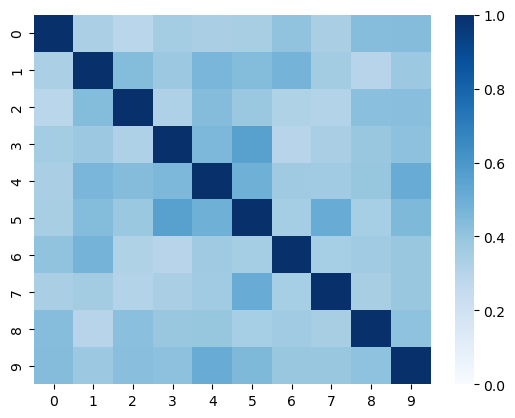

In [12]:
c = [[len(pairwise_intersections[i][j])/ len(pairwise_unions[i][j]) for j in range(N)] for i in range(N)]
sns.heatmap(c, cmap="Blues", vmin=0, annot=False)


In [13]:
circ = deactivated_circuit(model, inp_shape, device)
invert_masks(circ)
toggle_neurons(circ, torch.tensor(list(union)))
circuit_validation(circ, device)

/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `transforms.Compose([transforms.ToImageTensor(), transforms.ConvertImageDtype()])`.
  warnings.warn(
/home/cabbagepatch/miniconda3/envs/new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


isolation test
dict_values([0.9948979591735214, 0.9947136563789013, 0.9825581395253629, 0.9920792079109695, 0.991853360478698, 0.9921524663565902, 0.9916492693007135, 0.9961089494066527, 0.9404517453702212, 0.9722497522202949])
neccesity test
dict_values([0.012244897959058726, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9999999999897331, 0.003964321109970621])


In [14]:
len(np.sort(list(union)))

110

Step 0 | Act: 0.00 | TV: 1735.11


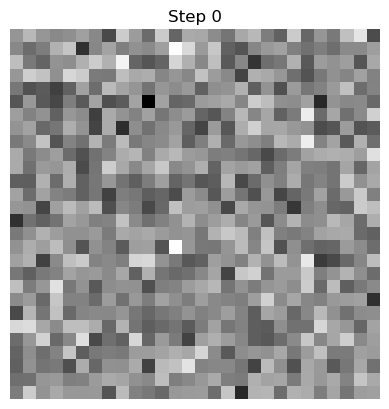

Step 100 | Act: 0.00 | TV: 12.08


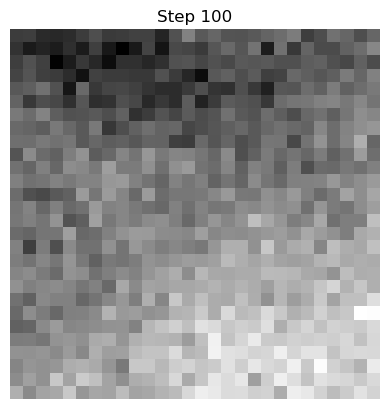

Step 200 | Act: 0.00 | TV: 10.60


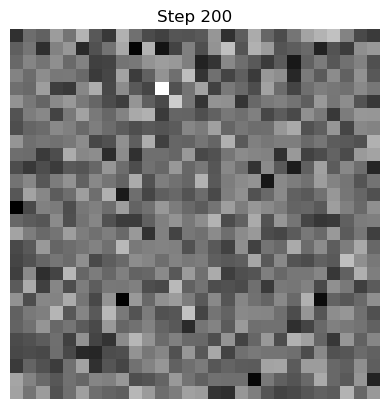

Step 300 | Act: 0.00 | TV: 10.10


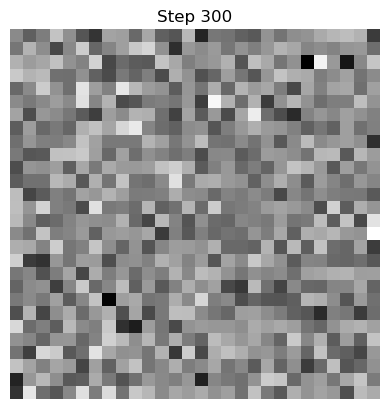

Step 400 | Act: 0.00 | TV: 10.51


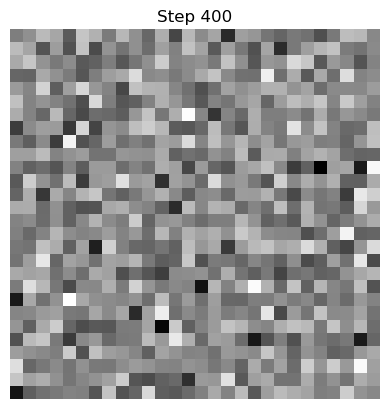

Step 500 | Act: 0.00 | TV: 10.26


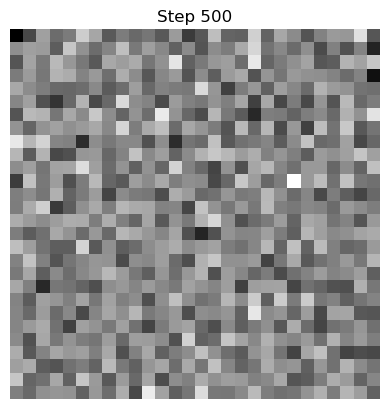

Step 600 | Act: 0.00 | TV: 10.16


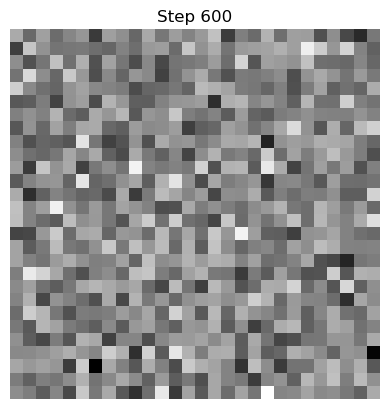

Step 700 | Act: 0.00 | TV: 9.80


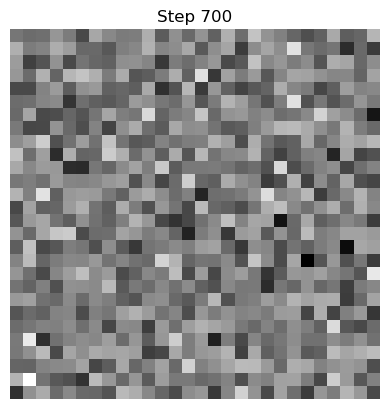

Step 800 | Act: 0.00 | TV: 9.23


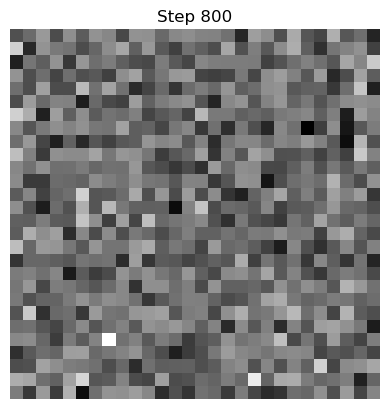

Step 900 | Act: 0.00 | TV: 9.62


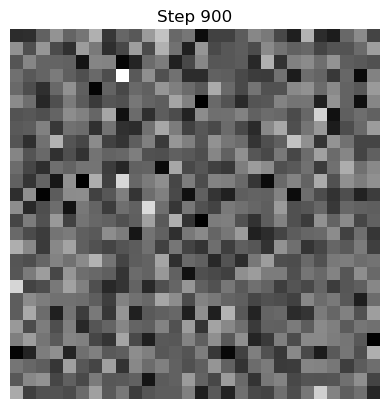

Step 1000 | Act: 0.00 | TV: 9.60


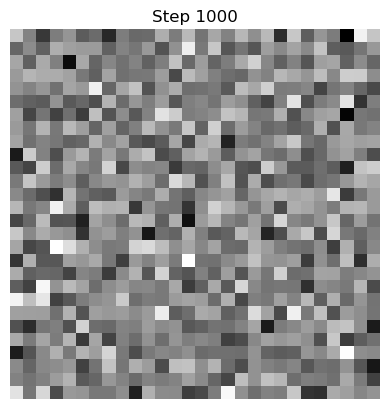

Step 1100 | Act: 0.00 | TV: 9.92


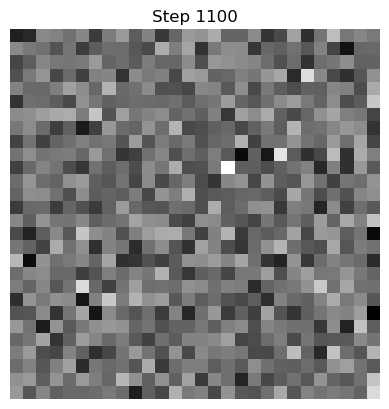

Step 1200 | Act: 0.00 | TV: 9.61


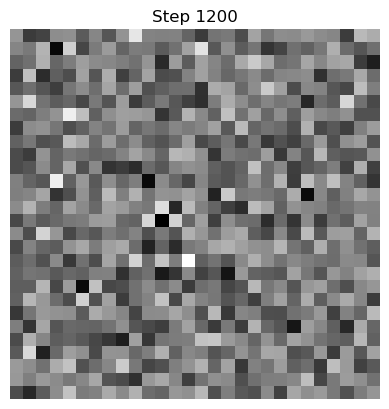

Step 1300 | Act: 0.00 | TV: 9.29


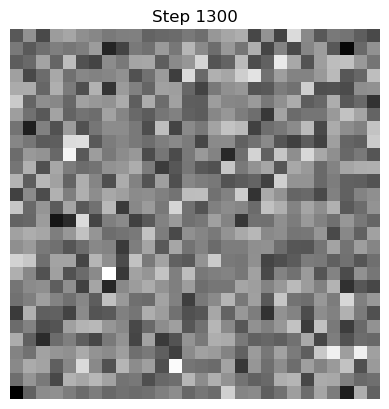

Step 1400 | Act: 0.00 | TV: 9.91


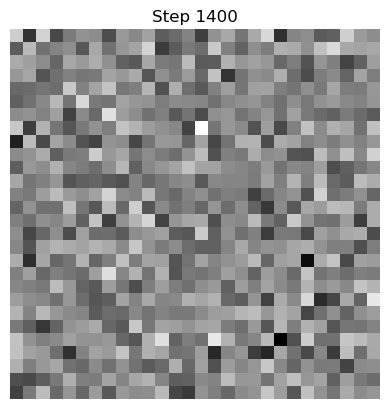

Step 1500 | Act: 0.00 | TV: 9.72


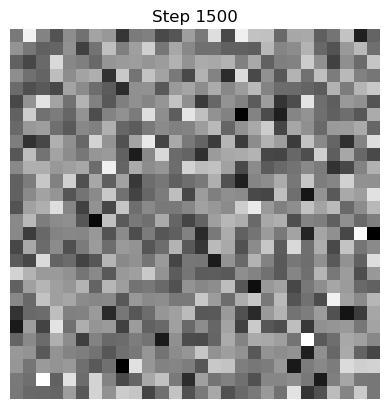

Step 1600 | Act: 0.00 | TV: 10.20


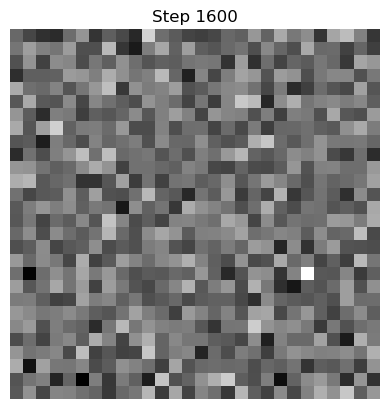

Step 1700 | Act: 0.00 | TV: 9.60


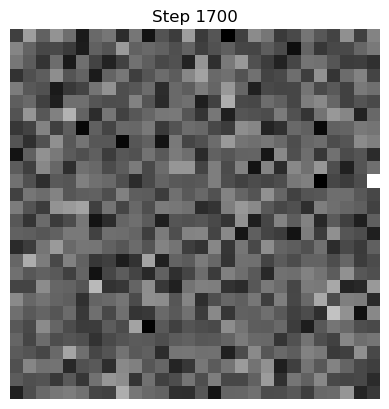

Step 1800 | Act: 0.00 | TV: 9.71


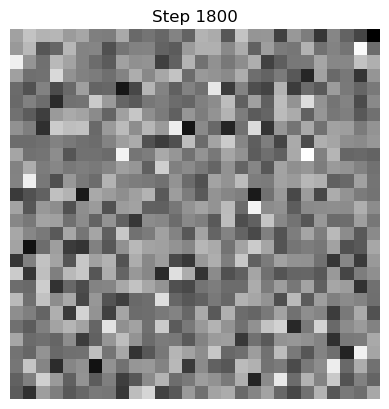

Step 1900 | Act: 0.00 | TV: 9.12


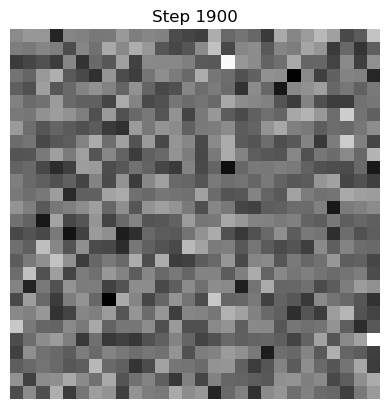

Step 1999 | Act: 0.00 | TV: 9.99


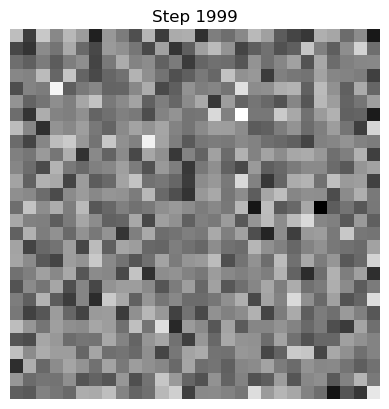

In [17]:
_ = vis(circ, np.sort(list(union))[100:], inp_shape, steps=2000, tv_weight=0.4, l2_weight=0.2)